**Stochatic Multi-Armed Bandit**

Complete the following code skeleton and answer the question in the assignment.

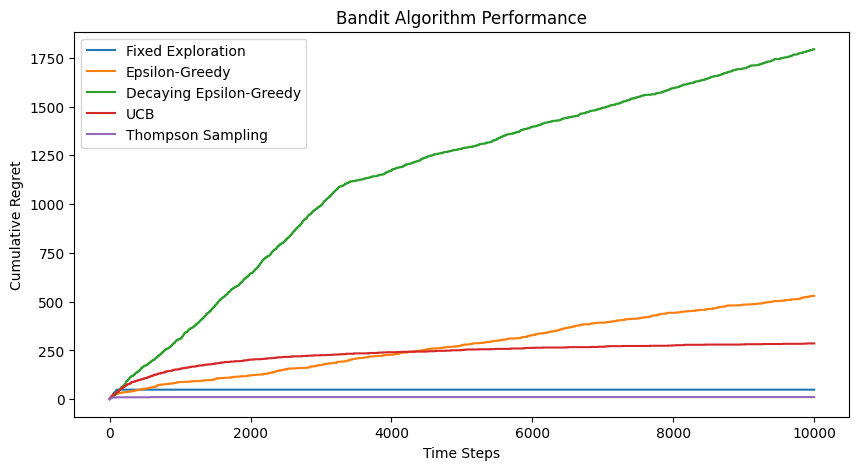

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Bandit Environment
class BanditEnvironment:
    def __init__(self, num_arms, reward_means):
        self.num_arms = num_arms
        self.reward_means = reward_means

    def pull_arm(self, arm):
        return np.random.binomial(1, self.reward_means[arm])  # Bernoulli rewards

# ==========================
# Fixed Exploration Then Exploitation 
# ==========================
class FixedExplorationThenGreedy:
    def __init__(self, num_arms, exploration_steps):
        self.num_arms = num_arms
        self.exploration_steps = exploration_steps
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)
        self.t = 1

    def select_arm(self):
        if self.t <= self.exploration_steps:  # Exploration phase
            return np.random.randint(self.num_arms)
        else:  # Exploitation phase
            return np.argmax(self.values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]  
        self.t += 1

# ==========================
# Epsilon-Greedy Algorithm 
# ==========================
class EpsilonGreedy:
    def __init__(self, num_arms, epsilon):
        self.num_arms = num_arms
        self.epsilon = epsilon
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)

    def select_arm(self):
        if np.random.rand() < self.epsilon:  # Exploration
            return np.random.randint(self.num_arms)
        else:  # Exploitation
            return np.argmax(self.values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

# ==========================
# Epsilon-Greedy with Decaying Exploration 
# ==========================
class EpsilonGreedyDecaying:
    def __init__(self, num_arms, epsilon_schedule):
        self.num_arms = num_arms
        self.epsilon_schedule = epsilon_schedule  # Function for epsilon_t
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)
        self.t = 1

    def select_arm(self):
        epsilon_t = self.epsilon_schedule(self.t)
        if np.random.rand() < epsilon_t:  # Explore
            return np.random.randint(self.num_arms)
        else:  # Exploit
            return int(np.argmax(self.values))

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm] 
        self.t += 1

# ==========================
# UCB Algorithm 
# ==========================
class UCB:
    def __init__(self, num_arms, c):
        self.num_arms = num_arms
        self.c = c
        self.counts = np.zeros(num_arms)
        self.values = np.zeros(num_arms)
        self.t = 1

    def select_arm(self): 
        # Ensure every arm is tried at least once
        for arm in range(self.num_arms):
            if self.counts[arm] == 0:
                return arm 

        ucb_values = self.values + np.sqrt(np.log(1 / self.c) / (2 * self.counts)) # you might want to modify the form
        return np.argmax(ucb_values)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm] 
        self.t += 1

# ==========================
# Thompson Sampling Algorithm 
# ==========================
class ThompsonSampling: 
    def __init__(self, num_arms, alpha_prior = 1, beta_prior = 1):
        self.num_arms = num_arms
        # modified to take care of the prior distrituion affectively
        self.successes = np.ones(num_arms) * alpha_prior
        self.failures = np.ones(num_arms) * beta_prior


    def select_arm(self):
        samples = [np.random.beta(self.successes[i], self.failures[i]) for i in range(self.num_arms)]

        return np.argmax(samples)

    def update(self, arm, reward):
        if reward == 1:
            self.successes[arm] += 1
        else:
            self.failures[arm] += 1

# ==========================
# Experiment Runner
# ==========================
def run_experiment(bandit_class, bandit_params, env, num_steps):
    bandit = bandit_class(**bandit_params)
    regrets = []
    optimal_reward = max(env.reward_means)

    for t in range(num_steps):
        arm = bandit.select_arm()
        reward = env.pull_arm(arm)
        bandit.update(arm, reward)
        regret = optimal_reward - reward
        regrets.append(regret)

    return np.cumsum(regrets)

# ==========================
# Running Experiments
# ==========================
num_arms = 10
reward_means = np.linspace(0, 1, num_arms)  # Linearly spaced rewards
env = BanditEnvironment(num_arms, reward_means)
num_steps = 10000

# Define epsilon schedule
def epsilon_schedule(t):
    return 1 / (t + 1)

# Plot setup
plt.figure(figsize=(10,5))

# Run and plot Fixed Exploration Then Exploitation
fixed_exploration_regret = run_experiment(FixedExplorationThenGreedy, {'num_arms': num_arms, 'exploration_steps': 100}, env, num_steps)
plt.plot(fixed_exploration_regret, label='Fixed Exploration')

# Run and plot ε-Greedy
epsilon_greedy_regret = run_experiment(EpsilonGreedy, {'num_arms': num_arms, 'epsilon': 0.1}, env, num_steps)
plt.plot(epsilon_greedy_regret, label='Epsilon-Greedy')

# Run and plot Decaying ε-Greedy
decaying_epsilon_greedy_regret = run_experiment(EpsilonGreedyDecaying, {'num_arms': num_arms, 'epsilon_schedule': epsilon_schedule}, env, num_steps)
plt.plot(decaying_epsilon_greedy_regret, label='Decaying Epsilon-Greedy')

# Run and plot UCB
ucb_regret = run_experiment(UCB, {'num_arms': num_arms, 'c': 0.00000000000001}, env, num_steps)
plt.plot(ucb_regret, label='UCB')

# Run and plot Thompson Sampling
thompson_regret = run_experiment(ThompsonSampling, {'num_arms': num_arms}, env, num_steps)
plt.plot(thompson_regret, label='Thompson Sampling')

# plot x= y 
# x = np.linspace(0, 10000, 1000000)  # 100 points from -10 to 10

# # Since y = x
# y = x

# # Plot
# plt.plot(x, y, linestyle=':', label='y = x', color='black')


plt.xlabel("Time Steps")
plt.ylabel("Cumulative Regret")
plt.legend()
plt.title("Bandit Algorithm Performance")
plt.show()

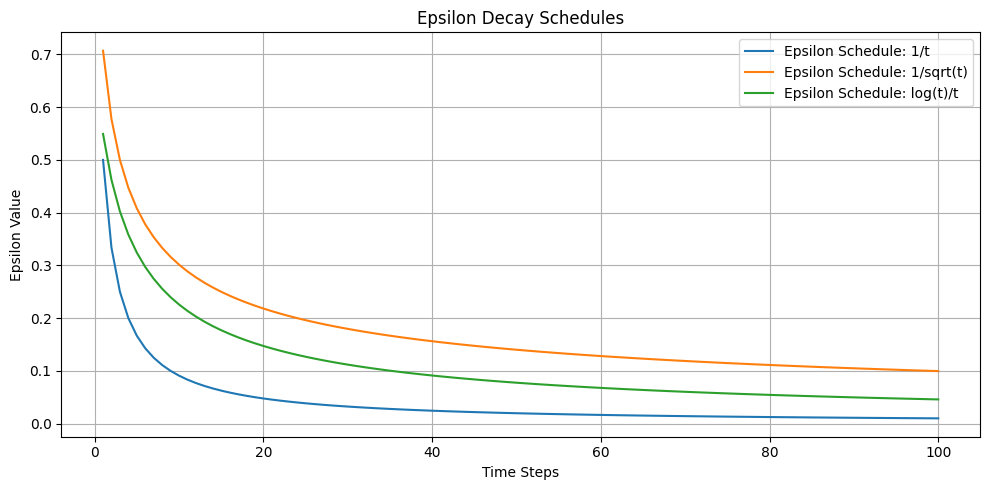

In [ ]:
num_steps = 100
t_values = np.arange(1, num_steps + 1)

# Epsilon schedule functions
schedules = {
    '1/t': lambda t: 1 / (t + 1),
    '1/sqrt(t)': lambda t: 1 / np.sqrt(t + 1),
    'log(t)/t': lambda t: np.log(t + 2) / (t + 1)
}

plt.figure(figsize=(10, 5))
for name, schedule in schedules.items():
    epsilon_values = [schedule(t) for t in t_values]
    plt.plot(t_values, epsilon_values, label=f'Epsilon Schedule: {name}')

plt.xlabel("Time Steps")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay Schedules")
plt.legend()
plt.grid(True)  
plt.tight_layout()
plt.show()

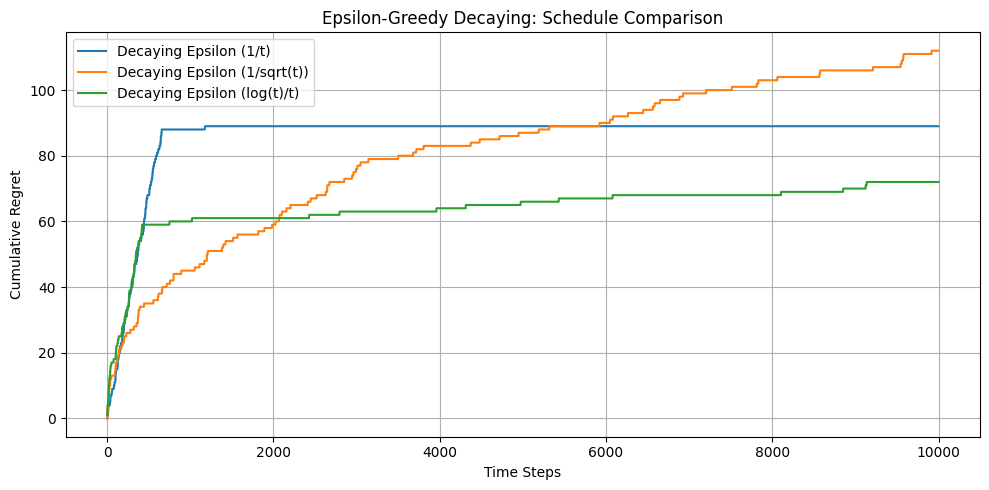

In [15]:
def run_experiment(schedule_name, schedule_fn, num_arms, reward_means, num_steps):
    env = BanditEnvironment(num_arms, reward_means)
    agent = EpsilonGreedyDecaying(num_arms, schedule_fn)
    optimal_reward = max(reward_means)
    regrets = []

    for _ in range(num_steps):
        arm = agent.select_arm()
        reward = env.pull_arm(arm)
        agent.update(arm, reward)
        regrets.append(optimal_reward - reward)

    return np.cumsum(regrets)


num_arms = 10
reward_means = np.linspace(0, 1, num_arms)
num_steps = 10000

# Epsilon schedule definitons
schedules = {
    '1/t': lambda t: 1 / (t + 1),
    '1/sqrt(t)': lambda t: 1 / np.sqrt(t + 1),
    'log(t)/t': lambda t: np.log(t + 2) / (t + 1)
}

plt.figure(figsize=(10, 5))
for name, sched in schedules.items():
    regret = run_experiment(name, sched, num_arms, reward_means, num_steps)
    plt.plot(regret, label=f'Decaying Epsilon ({name})')

plt.xlabel('Time Steps')
plt.ylabel('Cumulative Regret')
plt.title('Epsilon-Greedy Decaying: Schedule Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("regret_comparison.png", format='png', dpi=600, bbox_inches='tight')
plt.show()



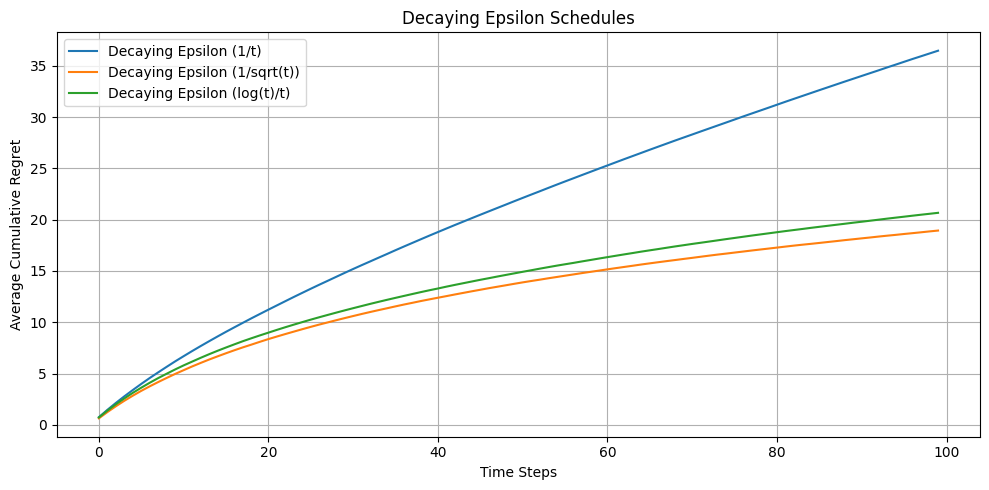

In [8]:
# One trial
def run_trial(schedule_fn, num_arms, reward_means, num_steps):
    env = BanditEnvironment(num_arms, reward_means)
    agent = EpsilonGreedyDecaying(num_arms, schedule_fn)
    optimal_reward = max(reward_means)
    regrets = []

    for _ in range(num_steps):
        arm = agent.select_arm()
        reward = env.pull_arm(arm)
        agent.update(arm, reward)
        regrets.append(optimal_reward - reward)

    return np.cumsum(regrets)

#  Calculation of means from multiple trials
def run_multiple_trials(schedule_name, schedule_fn, num_trials, num_arms, reward_means, num_steps):
    all_regrets = np.zeros(num_steps)
    for _ in range(num_trials):
        regrets = run_trial(schedule_fn, num_arms, reward_means, num_steps)
        all_regrets += regrets
    return all_regrets / num_trials

num_arms = 10
reward_means = np.linspace(0, 1, num_arms)
num_steps = 100
num_trials = 10000

# Epsilon schedule functions
schedules = {
    '1/t': lambda t: 1 / (t + 1),
    '1/sqrt(t)': lambda t: 1 / np.sqrt(t + 1),
    'log(t)/t': lambda t: np.log(t + 2) / (t + 1)
}


plt.figure(figsize=(10, 5))
for name, sched in schedules.items():
    avg_regret = run_multiple_trials(name, sched, num_trials, num_arms, reward_means, num_steps)
    plt.plot(avg_regret, label=f'Decaying Epsilon ({name})')

plt.xlabel('Time Steps')
plt.ylabel('Average Cumulative Regret')
plt.title(f'Decaying Epsilon Schedules')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
